# **Coursework Project**
### Part 1(a) Sampling using Random Walk Metropolis-Hastings

In [5]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# set seed to ensure produce same results
np.random.seed(123)  

In [7]:
# Define probability density function 
def f(x):
    return 0.5 * np.exp(-abs(x))

In [8]:
# Metropolis-Hastings Algorithm
def metropolis_hastings(N, s, x0=0):
    samples = np.zeros(N)
    samples[0] = x0
    
    for i in range(1, N):
        x_star = np.random.normal(samples[i - 1], s)
        r = f(x_star) / f(samples[i - 1])
        
        if np.log(np.random.uniform()) < np.log(r):
            samples[i] = x_star
        else:
            samples[i] = samples[i - 1]
    
    return samples

In [9]:
# Generate samples
N = 10000
s = 1
samples = metropolis_hastings(N, s)

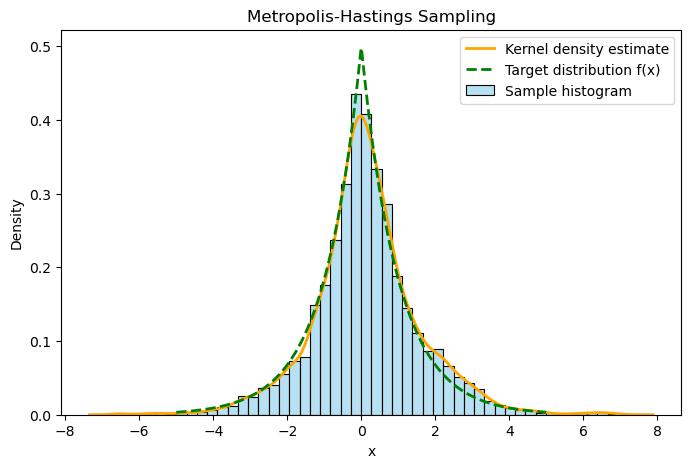

In [17]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Plot histogram
sns.histplot(samples, bins=50, stat="density", color="skyblue", alpha=0.6, label="Sample histogram", ax=ax)

# Plot Kernel Density Estimate (KDE)
sns.kdeplot(samples, color="orange", linewidth=2, label="Kernel density estimate", ax=ax)

# Overlay the true density function
x_vals = np.linspace(-5, 5, 1000)
ax.plot(x_vals, f(x_vals), 'g--', linewidth=2, label="Target distribution f(x)")

# Labels and title
ax.set_title("Metropolis-Hastings Sampling")
ax.set_xlabel("x")
ax.set_ylabel("Density")

# Add legend with customized style
ax.legend()

# Show plot
plt.show()

In [18]:
# Monte Carlo estimates (mean and standard deviation)
sample_mean = np.mean(samples)
sample_sd = np.std(samples)
print(f"Monte Carlo Mean: {sample_mean}")
print(f"Monte Carlo SD: {sample_sd}")

Monte Carlo Mean: 0.13218160322129116
Monte Carlo SD: 1.4309633105043644


### Part 1 (b) Convergence Diagnostic (R-hat)

In [19]:
#Compute R-hat diagnostic
def compute_r_hat(N, s, J, init_values):
    chains = np.zeros((N, J))
    
    for j in range(J):
        chains[:, j] = metropolis_hastings(N, s, x0=init_values[j])
    
    Mj = np.mean(chains, axis=0)
    Vj = np.var(chains, axis=0, ddof=1)
    
    W = np.mean(Vj)
    M = np.mean(Mj)
    B = np.mean((Mj - M) ** 2)
    
    R_hat = np.sqrt((B + W) / W)
    return R_hat

In [20]:
# Generate R-hat values over grid of s
s_values = np.linspace(0.001, 1, 50)
R_hat_values = [compute_r_hat(N=2000, s=s, J=4, init_values=[-5, 0, 5, 10]) for s in s_values]

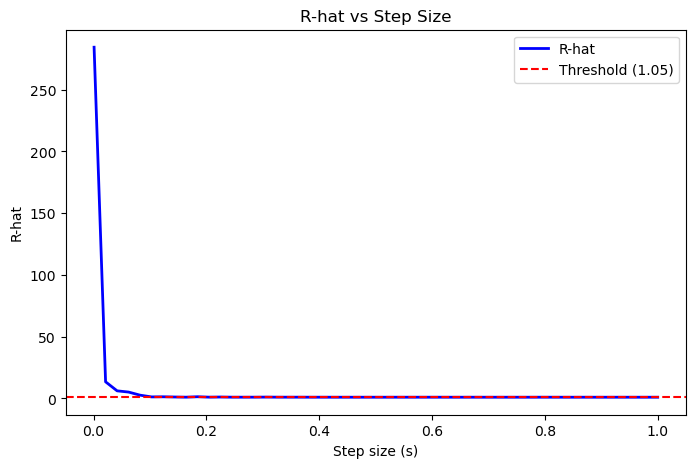

In [21]:
# Plot R-hat vs s
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(s_values, R_hat_values, 'b-', linewidth=2, label="R-hat")

# Add threshold line for convergence (1.05)
ax.axhline(y=1.05, color='r', linestyle='--', label="Threshold (1.05)")

# Labels and Title
ax.set_xlabel("Step size (s)")
ax.set_ylabel("R-hat")
ax.set_title("R-hat vs Step Size")
ax.legend()

# Show plot
plt.show()